7. Vaja - Resonanca

Navadno dušeno nihanje brez vsiljevanja:

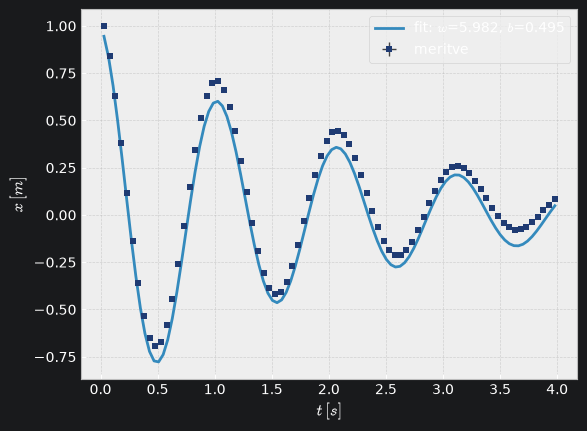

ω = 5.9823 ± 0.0282 rad/s
b = 0.4950 ± 0.0191 s⁻¹


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

plt.style.use('bmh')

df = pd.read_csv("meritve/taj1-1.csv", delimiter=";", decimal=",")

x = df.iloc[:,0].to_numpy()
y = df.iloc[:,1].to_numpy()

pre_cutoff = 0.57
mask = x >= pre_cutoff
x = x[mask] - pre_cutoff
y = y[mask]

cutoff = 4
mask = x <= cutoff
x = x[mask]
y = y[mask]

y = y / np.max(np.abs(y))

def f(t, omega, decay, phase):
    return np.cos(omega*t + phase) * np.exp(-decay*t)

# Fit - ADD PHASE TO p0
params, cov = curve_fit(f, x, y, p0=[5.0, 0.3, 0.0])  # ← 3 initial guesses now
omega, decay, phase = params  # ← unpack 3 parameters
errors = np.sqrt(np.diag(cov))

# Plot
plt.errorbar(
    x, y,
    yerr=0, xerr=0,
    fmt='s',
    markersize=4,
    color='#1f3b73',
    ecolor='#444444',
    elinewidth=1,
    capsize=3,
    capthick=1,
    markeredgewidth=0,
    linestyle='none',
    label='meritve'
)

x_fit = np.linspace(min(x), max(x), 100)
y_fit = f(x_fit, omega, decay, phase)
plt.plot(x_fit, y_fit,
         label=f'fit: $w$={omega:.3f}, $b$={decay:.3f}',
         linewidth=2)

plt.legend()
plt.xlabel(r"$t\,[s]$")
plt.ylabel(r"$x\,[m]$")
plt.savefig("graf1test.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"ω = {omega:.4f} ± {errors[0]:.4f} rad/s")
print(f"b = {decay:.4f} ± {errors[1]:.4f} s⁻¹")


Iz **normiranega** grafa določimo koeficient dušenja $\beta = (0.50 \pm 0.02) s^{-1}$, lastno kotno frekvenco $\Omega_0 = (6.00 \pm 0.03) rad/s$ in relativno stopnjo dušenja $\frac{\beta}{\Omega_0} = (0.0833 \pm 0.003)rad$.

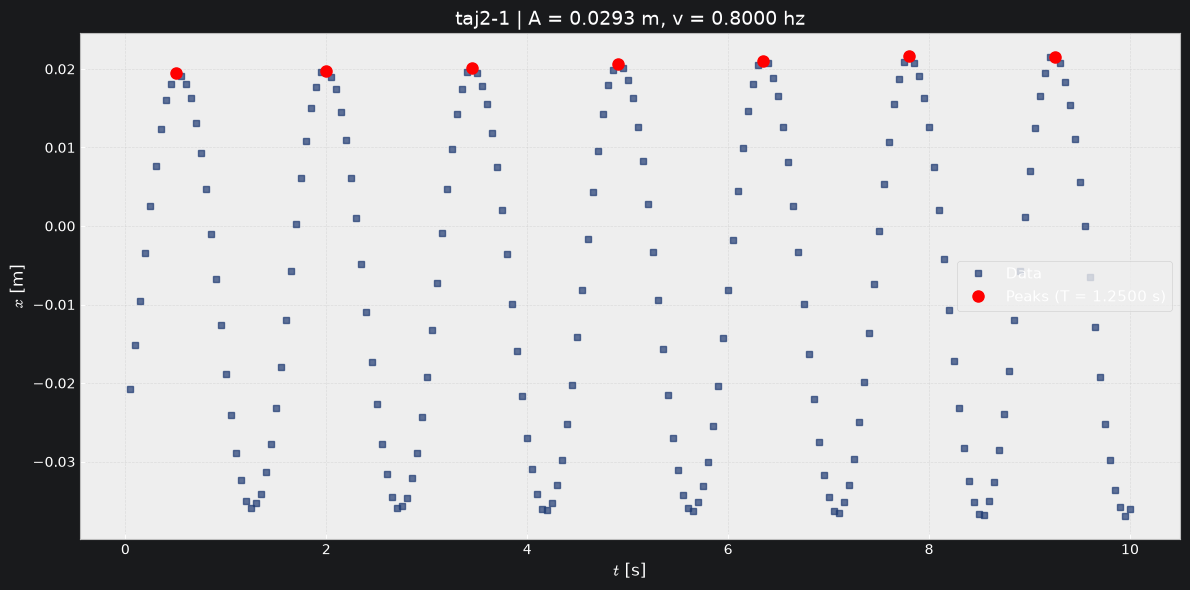

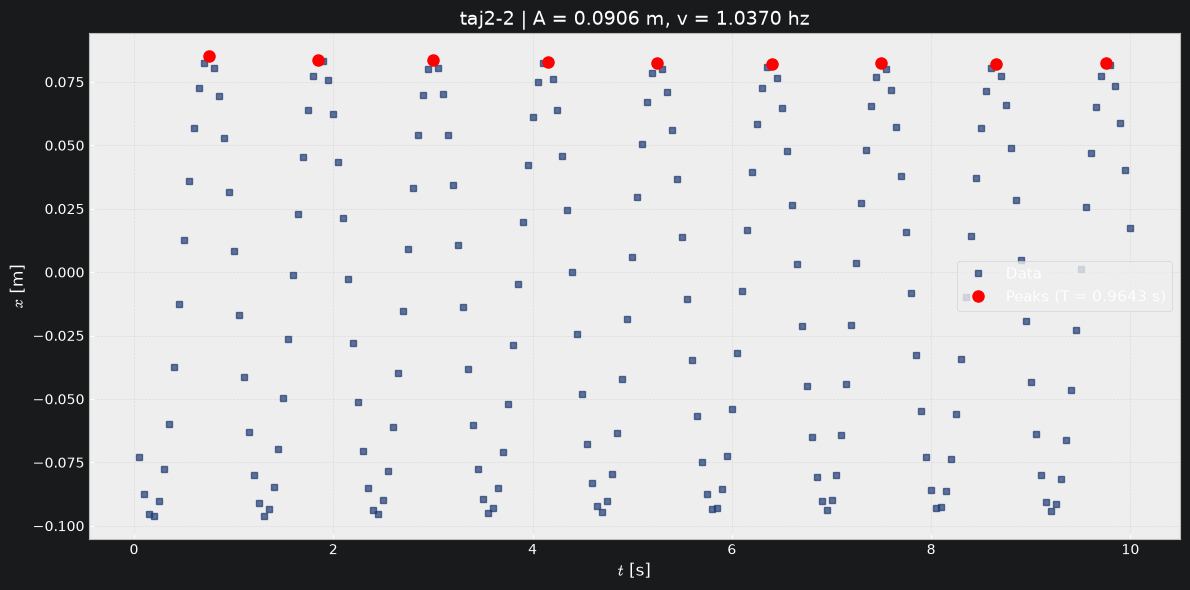

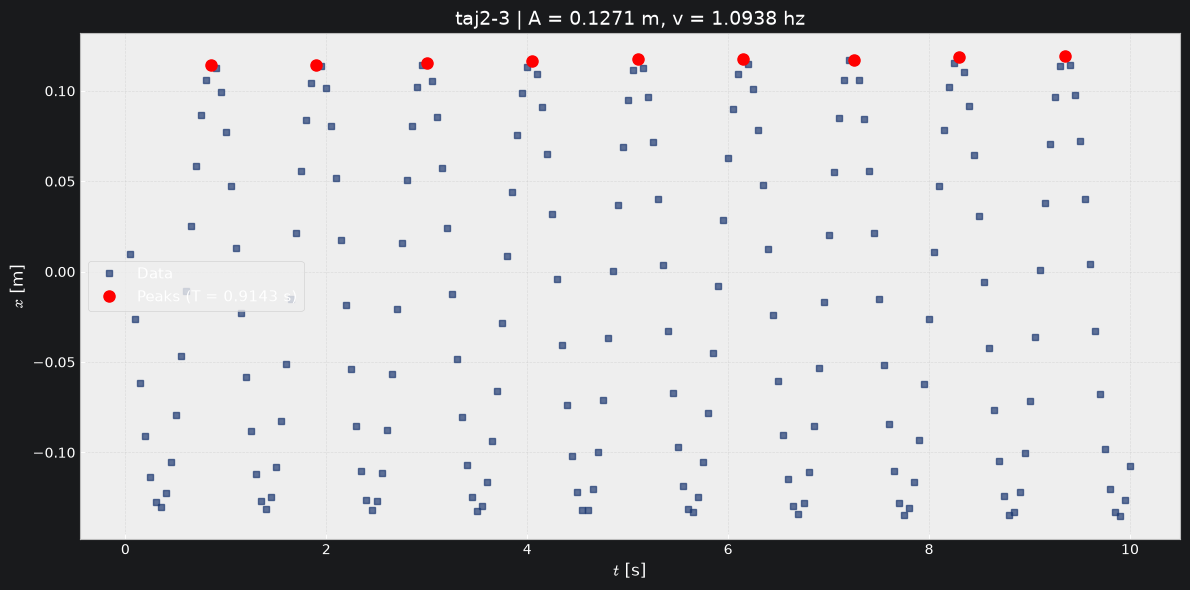

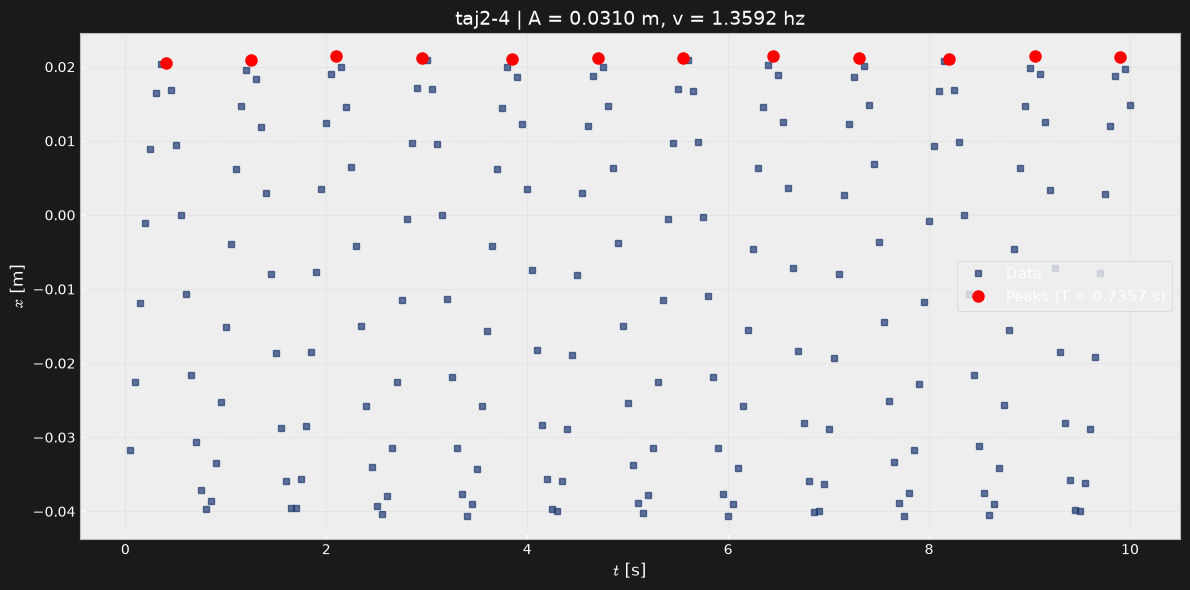

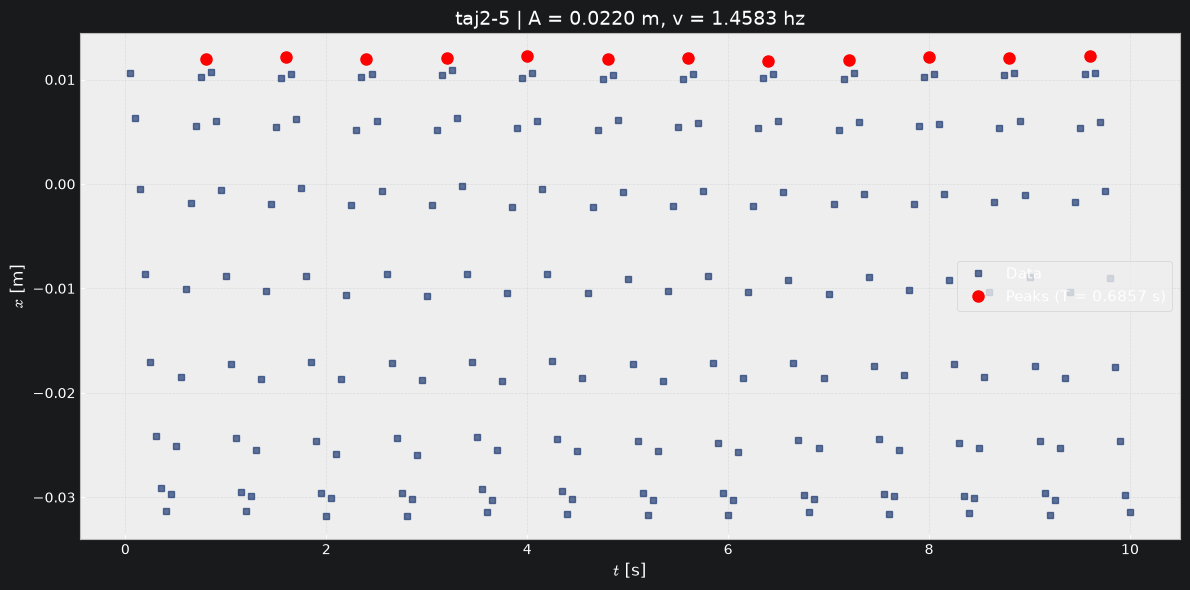

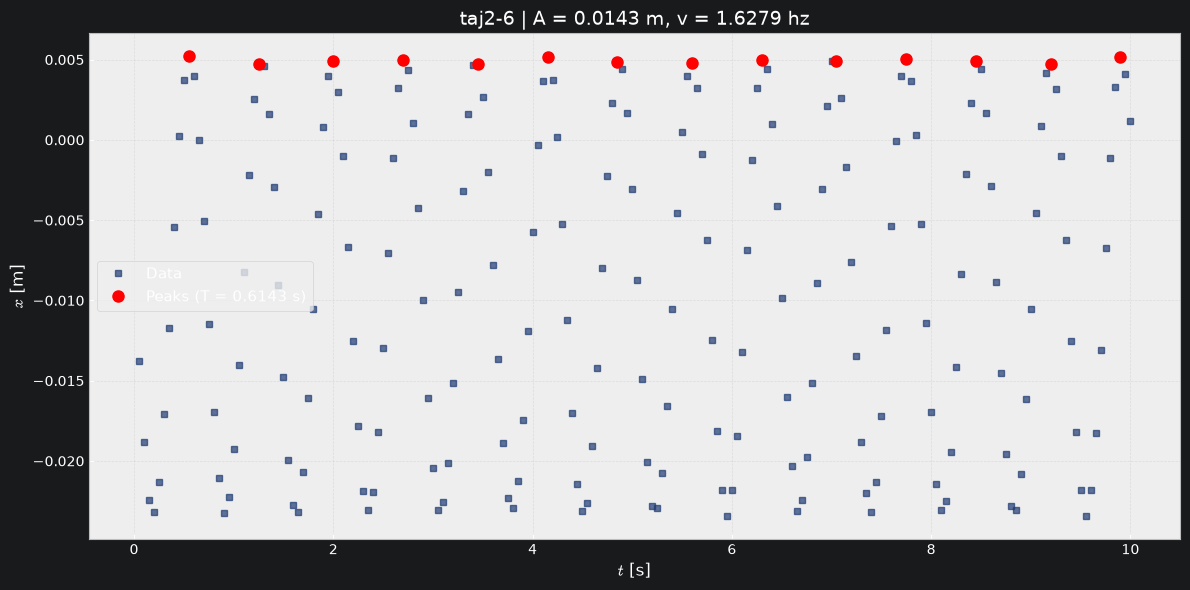

✗ taj2-7: Error - index 6 is out of bounds for axis 0 with size 6


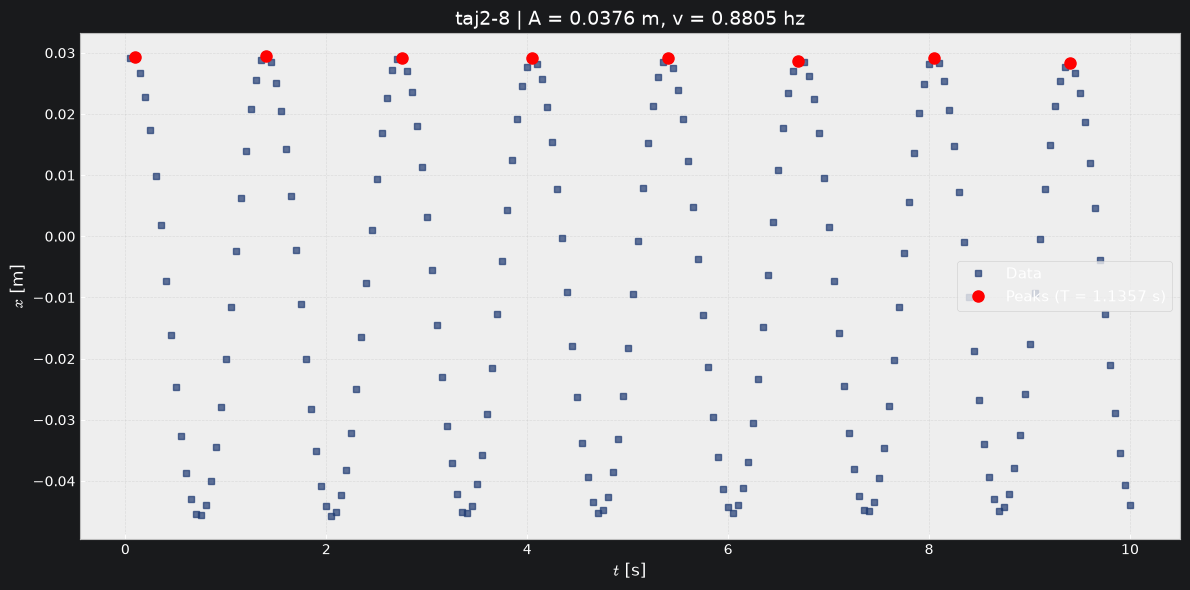

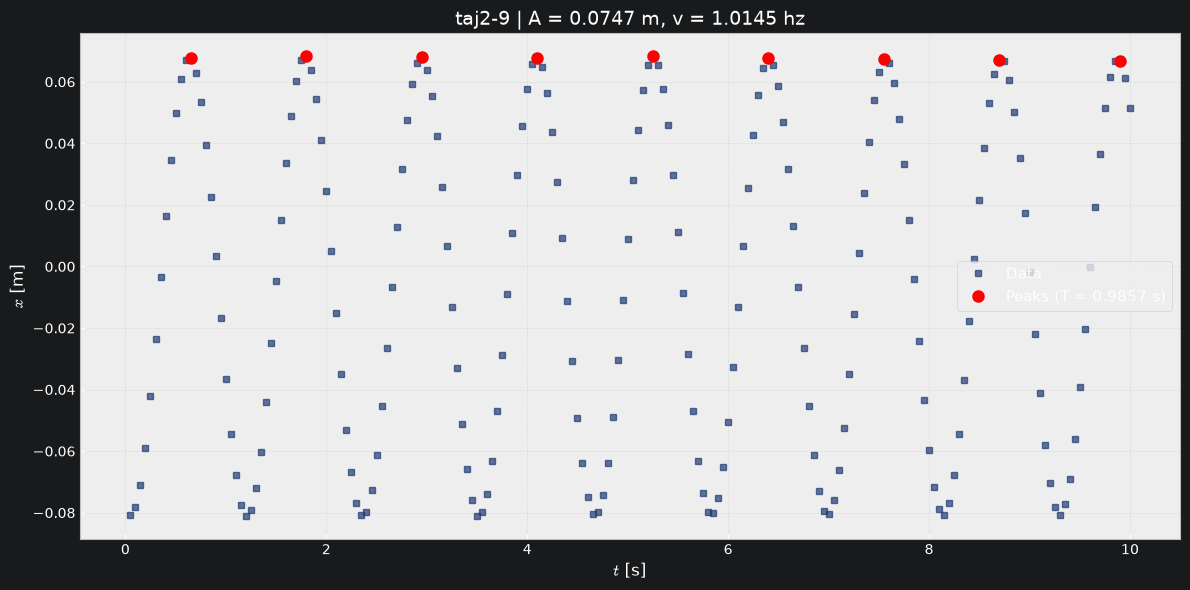

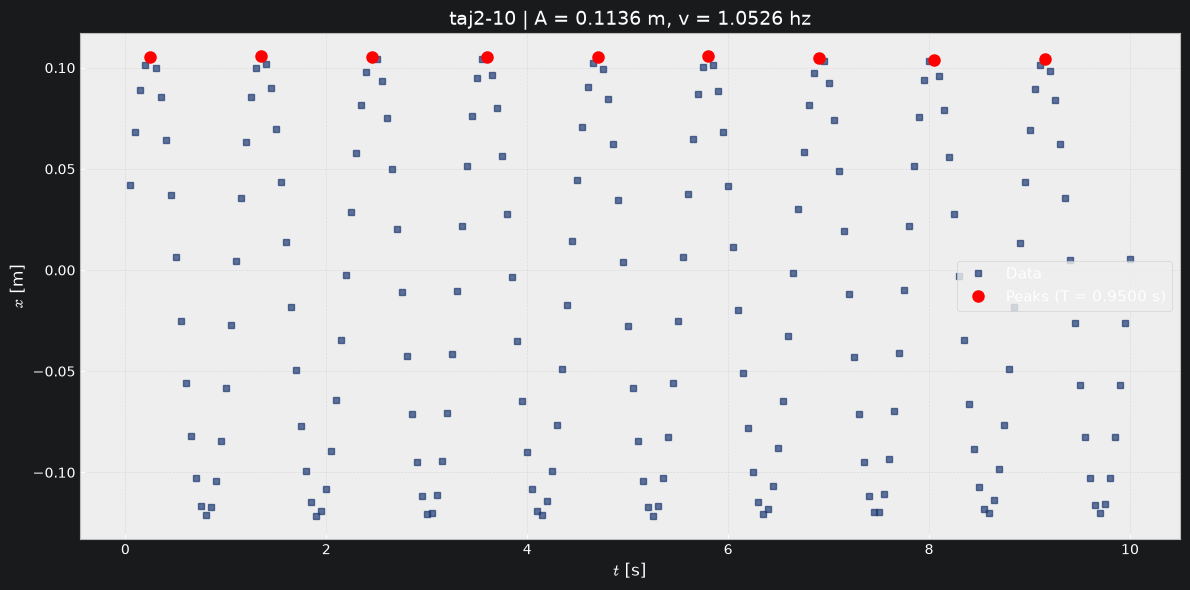

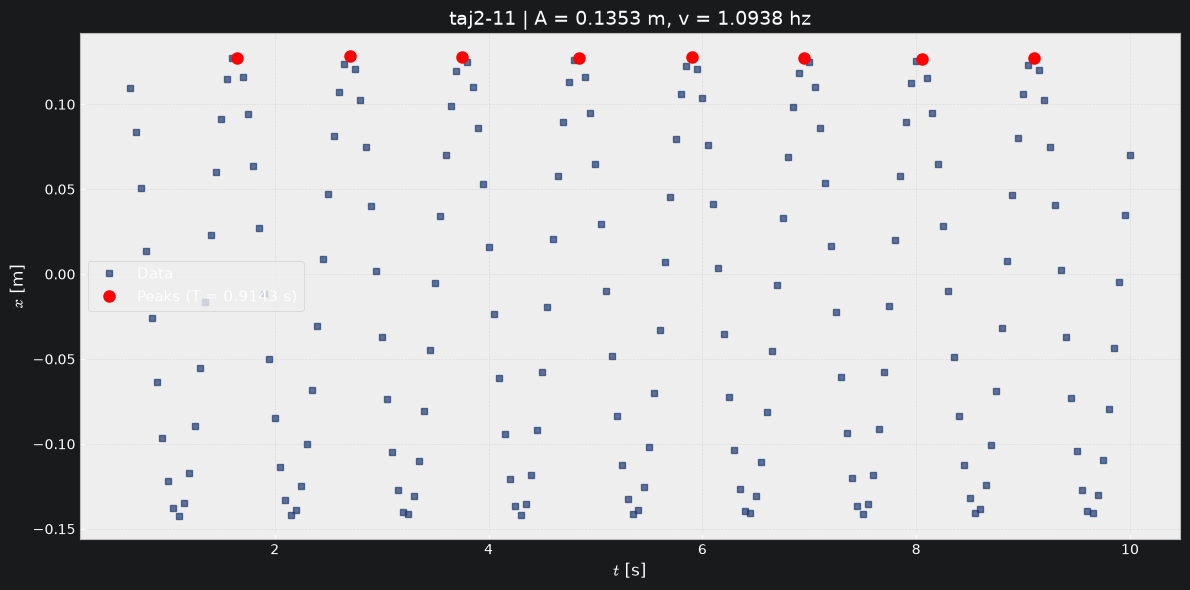

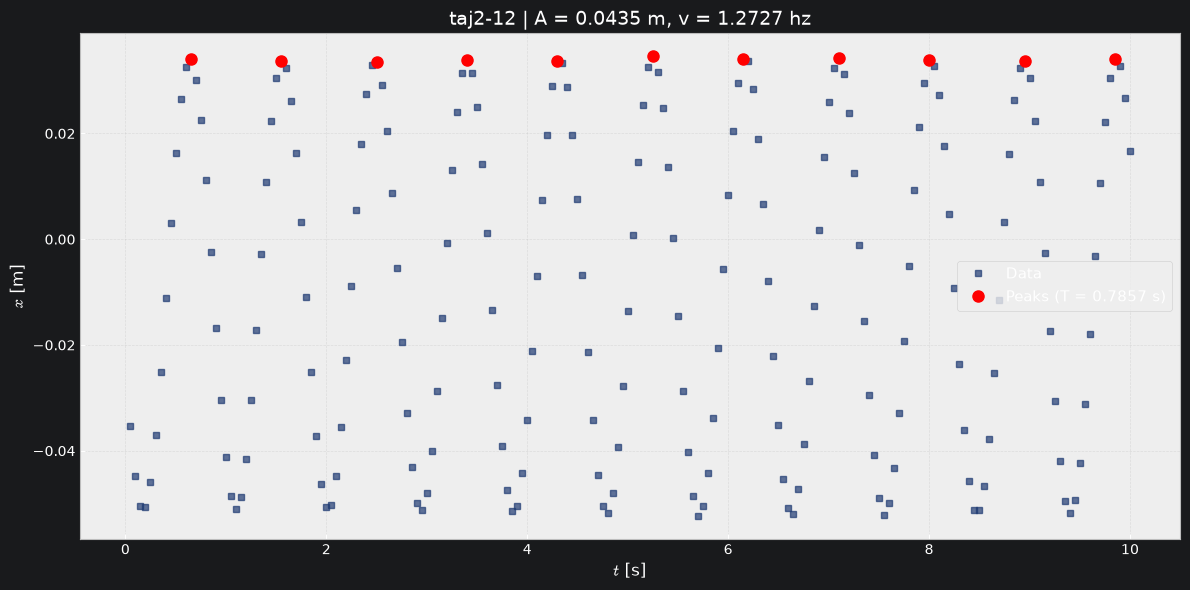

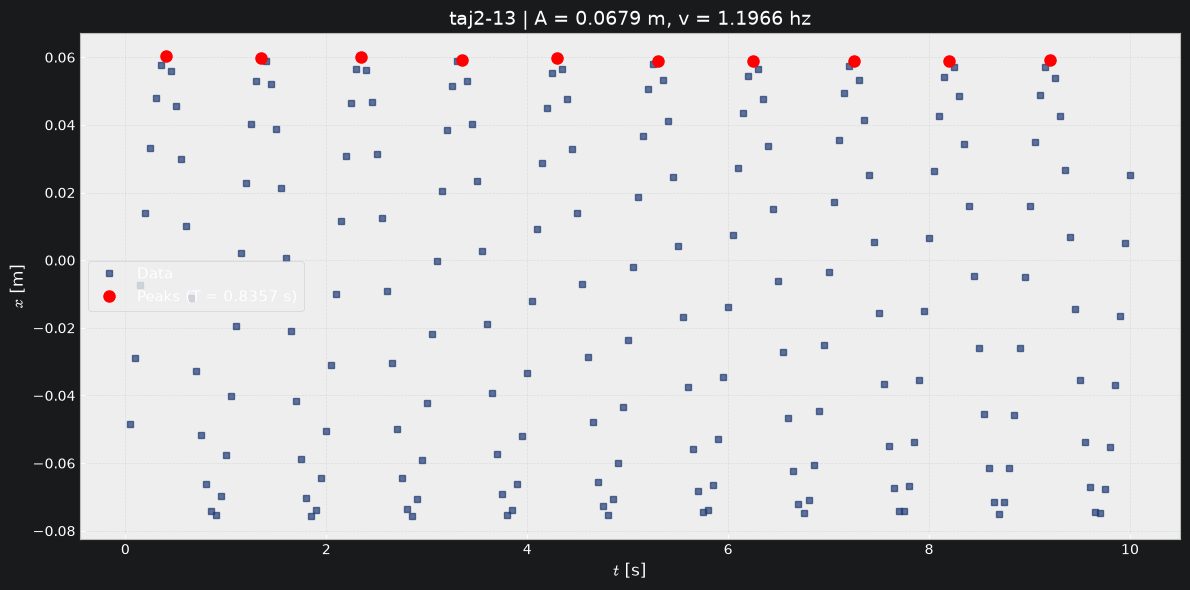

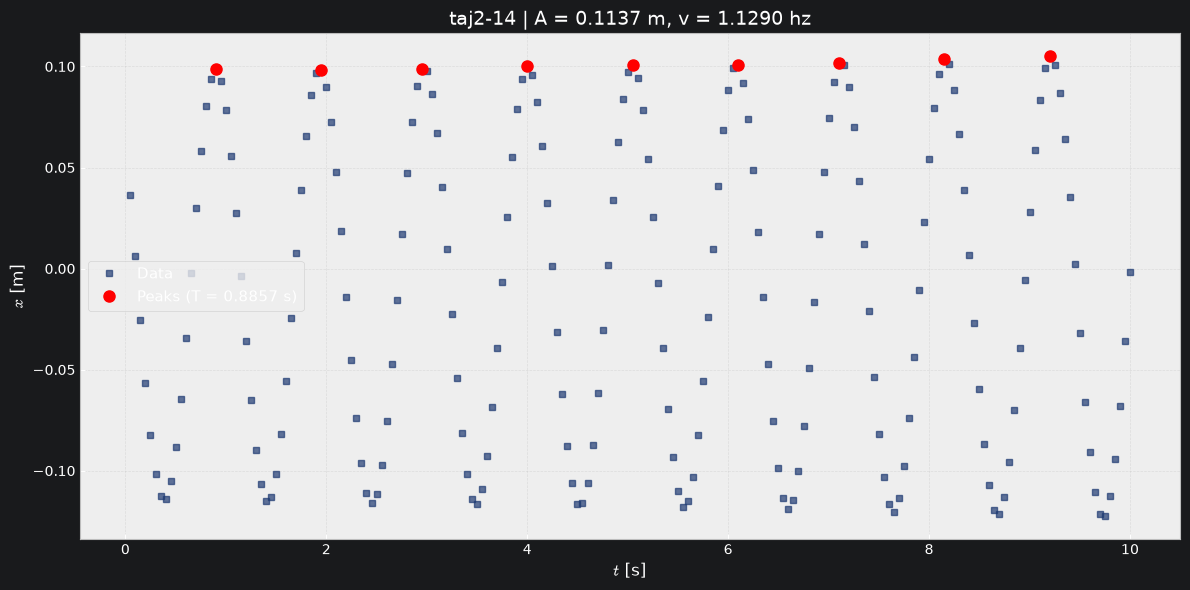

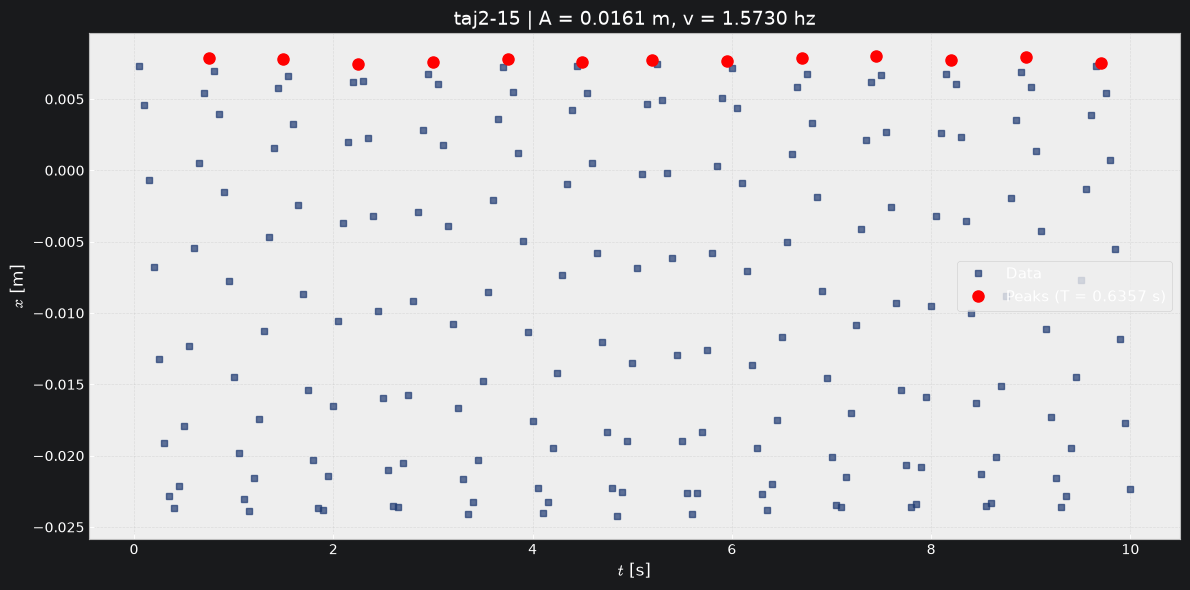

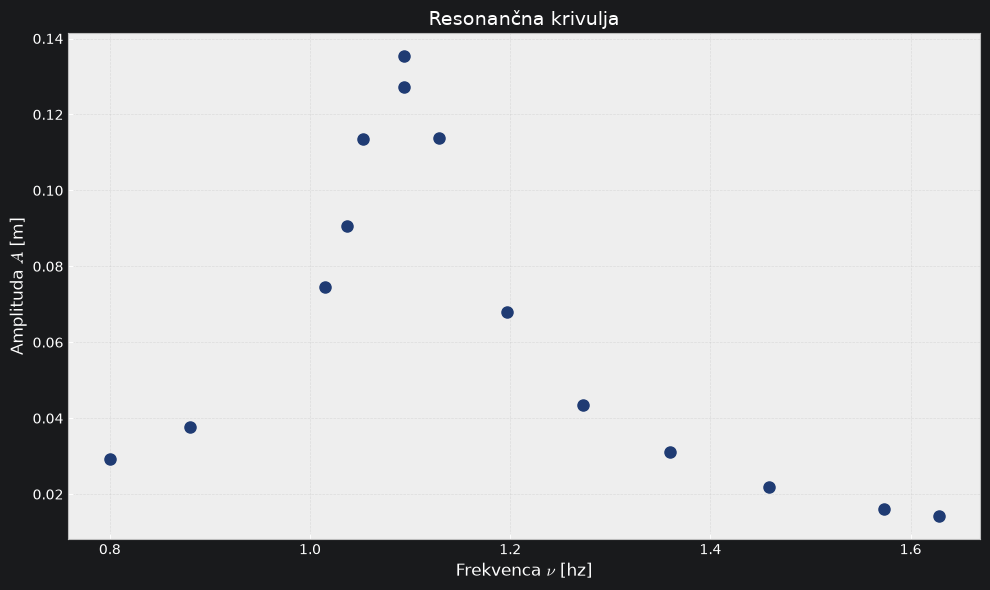

       file  amplitude  frequency_hz
0    taj2-1   0.029264      0.800000
1    taj2-2   0.090595      1.037037
2    taj2-3   0.127136      1.093750
3    taj2-4   0.031013      1.359223
4    taj2-5   0.022011      1.458333
5    taj2-6   0.014316      1.627907
6    taj2-8   0.037573      0.880503
7    taj2-9   0.074670      1.014493
8   taj2-10   0.113589      1.052632
9   taj2-11   0.135319      1.093750
10  taj2-12   0.043456      1.272727
11  taj2-13   0.067943      1.196581
12  taj2-14   0.113711      1.129032
13  taj2-15   0.016109      1.573034


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd
from pathlib import Path

plt.style.use('bmh')

results = []

for i in range(1, 16):
    filepath = f"meritve/taj2-{i}.csv"

    if not Path(filepath).exists():
        print(f"not found: {filepath}")
        continue

    try:
        df = pd.read_csv(filepath, delimiter=";", decimal=",")
        x = df.iloc[:,0].to_numpy()
        y = df.iloc[:,1].to_numpy()

        pre_cutoff = 0.
        mask = x >= pre_cutoff
        x = x[mask] - pre_cutoff
        y = y[mask]

        cutoff = 400
        mask = x <= cutoff
        x = x[mask]
        y = y[mask]

        #najde maximume in razdalje med njimi
        amplitude = (np.max(y) - np.min(y)) / 2
        peaks, _ = find_peaks(y)

        sample_peaks = 7
        t_peak1 = x[peaks[0]]
        t_peak2 = x[peaks[sample_peaks -1]]
        period = (t_peak2 - t_peak1)/sample_peaks
        frequency = 1 / period  # w = 2 pi /T

        results.append({
            'file': f'taj2-{i}',
            'amplitude': amplitude,
            'frequency_hz': frequency,
        })

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(x, y, 's', markersize=4, color='#1f3b73', label='Data', alpha=0.7)
        plt.plot(x[peaks], y[peaks], 'ro', markersize=8, label=f'Peaks (T = {period:.4f} s)')

        plt.xlabel(r"$t$ [s]", fontsize=12)
        plt.ylabel(r"$x$ [m]", fontsize=12)
        plt.title(f"taj2-{i} | A = {amplitude:.4f} m, v = {frequency:.4f} hz", fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"✗ taj2-{i}: Error - {e}")

if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv("fit_data.csv", index=False)

    #koncni plot
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['frequency_hz'], results_df['amplitude'],
             'o', markersize=8, linewidth=2, color='#1f3b73')

    plt.xlabel(r"Frekvenca $\nu$ [hz]", fontsize=12)
    plt.ylabel(r"Amplituda $A$ [m]", fontsize=12)
    plt.title("Resonančna krivulja", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(results_df)

Meritev 9: je dosegla resonančni vrh pri maksimalnem odmiku $A = 0.135 m$ in frekvenci $\nu = 1.093 hz$